# PSF of unaberrated system in Python

https://colab.research.google.com/github/Gchirico63/Didattica/blob/main/PhysicalPropagation/PSF_Aberrated.ipynb


In [3]:
# setup the matplotlib graphics library and configure it to show
# figures inline in the notebook
#%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.cm as cm

import numpy as np # this contains the array definitions
from numpy.fft import * # we import all FFT functions (we can write simply fft2)
from scipy.special import j1


This is a code to compute the PSF in various cases. Year 2026

Set the dimensions and define an aperture. We begin with Alice's case.
Parameters:

*  size = 128              ######## number of pixels
*   focal     = 50  ## focal length in mm
*   pupil_rad = 25  ## mm  full diamter of the lens in mm
*   diaph     = 10   ### diaphragrm in mm, the real size of the pupil
*   wave      = 0.55e-3   ### wavelength in mm

The exact PSF is the absolute square of the Coherent Spread Function thatis the FT of the pure real pupil defined as $$P(t) = 1 \;\; if \; \; r\le a$$ and  0 otherwise. The analytical expression is given in the next text box in terms of  the Bessel function $J_1$.

In the codes, you find a few parameters to change. The pupil radius is actually the lens radius. The effective size of the pupil is regulated by $\textit{diaph}$.  

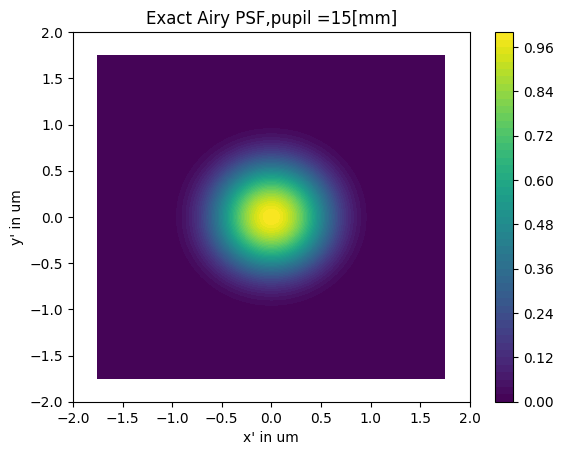

In [10]:
def Compute_exactPSF(size,pupil_rad,wave,focal):
  ximax     = 6
  xprimeMax = wave * focal * ximax / (2*np.pi*pupil_rad)
  dxprime   = xprimeMax / size
  xpp       = np.linspace(-xprimeMax,xprimeMax,size)
  xxp,yyp   = np.meshgrid(xpp,xpp)
  rr1p = (2*np.pi*pupil_rad)/(wave*focal) * np.sqrt(xxp*xxp+yyp*yyp)
  rr1p[rr1p == 0] = 1e-12

  y = (2*j1(rr1p)/rr1p)**2
  return y, xxp, yyp


###################################################
size = 128              ######## number of pixels
########## PLEASE CHANGE DIAPH HERE
focal     = 50  ##mm
pupil_rad = 25  ## mm  fukll diamter of the lens
diaph     = 15
dx        = pupil_rad / size   ### pixel size on the pupil
wave      = 0.55e-3   ### mm

(w, h) = (size,size)
ap = np.zeros((w, h))    ####  define a matrix of zeros

a, b = (w//2, h//2)
r = diaph*(size/pupil_rad)/2  ### radius of the diaphragmated pupil in pixels

y,x = np.ogrid[-a:w-a, -b:h-b]    ##  define a
circle = x*x + y*y <= r*r         ### these are the indeces for the circular mask
# THIS IS THE POINT WEHR WE DEFINE THE PUPIL FUNCTION, HERE IT IS PURELY REAL.
ap[circle] = 1

#### real coordinate on the pupil
xp = dx * (np.linspace(-size//2,size//2,1))
xxp,yyp     = np.meshgrid(xp,xp)

PSF_esatta, xxp, yyp = Compute_exactPSF(size,diaph,wave,focal)
plt.figure()
plt.contourf(xxp*1000, yyp*1000, PSF_esatta, levels=50, cmap='viridis')
plt.colorbar()
plt.xlabel('x\' in um')
plt.ylabel('y\' in um')
plt.xlim(-2,2)
plt.ylim(-2,2)
plt.title("Exact Airy PSF,pupil ="+str(diaph)+'[mm]')
plt.show()






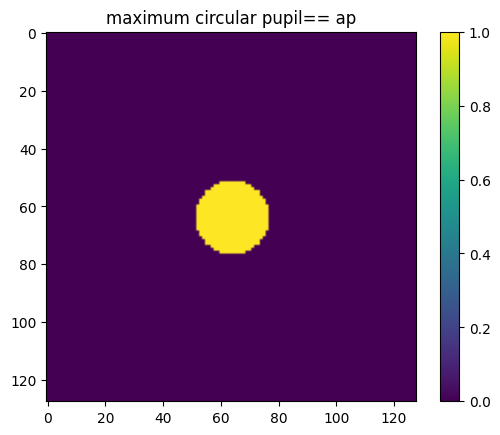

In [5]:
'''    show the circular mask'
'''

plt.imshow(ap)
plt.colorbar()
plt.title('maximum circular pupil== ap')
plt.show()

This is our aperture $A$. For the aberration free case, the Airy pattern $p$ is calculated by
$$ p = |\mathcal{F}(A)|^2, $$
where $\mathcal{F}$ is the Fourier transform.

Notice that the sampling defines the resolution.

We can  calculate that the Airy function for a perfect real tube function is:
$$ p(x,y) = \left( 2\frac{J_1(\xi)}{\xi}\right)^2 $$
where $\xi= \frac{2\pi a r}{\lambda f}$, $r$ is the radial coordinate in the imager plane, $\lambda$ is the wavelength and $f$ is the focal length of the lens.

the shape of th4e Airy function is: (128, 128)


Text(0.5, 1.0, 'phase [rads]')

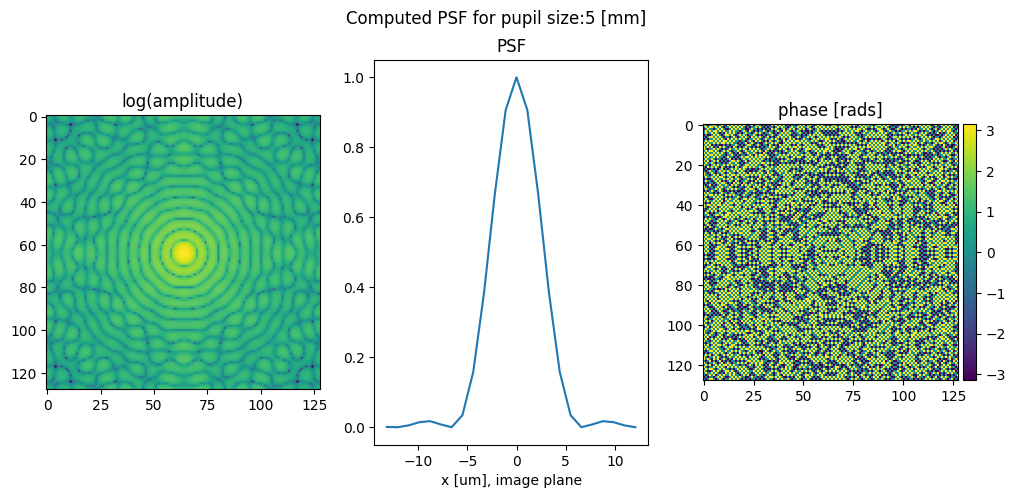

In [6]:
######## Her we compute the PSF numerically by performing nthe Fourier TRansform
### the pupil fiunction ap is defined above

airy      = np.abs(np.fft.fftshift(np.fft.fft2(ap)))**2
phase     = np.angle(np.fft.fftshift(np.fft.fft2(ap)))
####coordinates  in the image plane
xprime    = wave * focal * np.fft.fftshift(np.fft.fftfreq(size,dx)) ### coordinate in the image plane

 # don't forget fftshift and ifftshift!
print ('the shape of th4e Airy function is:',airy.shape)
Nairy     = airy.shape[0]

titolo = 'Computed PSF for pupil size:'+str(diaph)+' [mm]'
F,A     = plt.subplots(1,3,figsize=(12,5))
F.suptitle(titolo)
A[0].imshow(np.log(airy))
A[0].set_title('log(amplitude)')
m       = 12
A[1].plot(1000*xprime[Nairy//2 - m: Nairy//2 +m] , airy[Nairy // 2,Nairy//2 - m: Nairy//2 +m]/airy.max())
A[1].set_xlabel('x [um], image plane')
A[1].set_title('PSF')

from mpl_toolkits.axes_grid1 import make_axes_locatable

i2 = A[2].imshow(phase)
divider = make_axes_locatable(A[2])
cax = divider.append_axes("right", size="5%", pad=0.05)

plt.colorbar(i2, cax=cax)
A[2].set_title('phase [rads]')


Dirty trick from Oleg: with the magic below I make the PSF 7 pixels wide! for a better computation of the FT.

(448, 448)


Text(0.5, 0, 'x [um]')

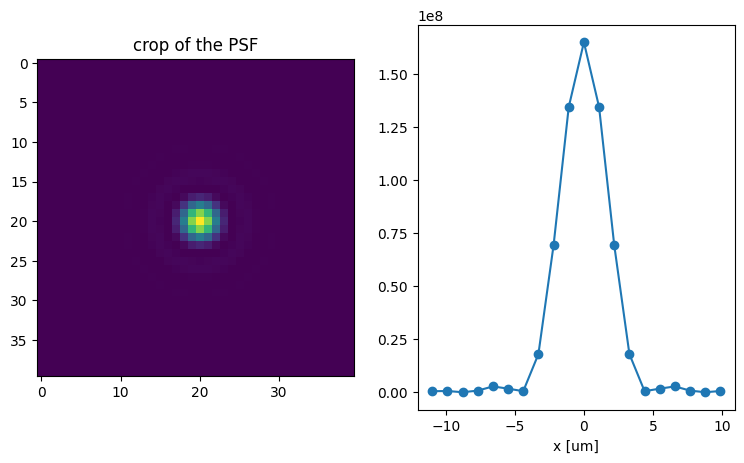

In [7]:
size = 128*7//2

(w, h) = (size,size)
ap = np.zeros((w, h))

a, b = (w//2, h//2)
dx        = pupil_rad / size   ### pixel size on the pupil7
r = 128/2 * dx

y,x = np.ogrid[-a:w-a, -b:h-b]
x = dx * x
y = dx * y
circle = x*x + y*y <= r*r

ap[circle] = 1
airy      = np.abs(np.fft.fftshift(np.fft.fft2(ap)))**2
print (airy.shape)
####coordinates  in the image plane
xprime      = wave * focal * np.fft.fftshift(np.fft.fftfreq(size,dx))
#airy = Null # This line shoud be restored, of course
F,A     = plt.subplots(1,2,figsize=(9,5))

A[0].imshow(airy[size//2-20:size//2+20 , size//2-20:size//2+20])
A[0].set_title('crop of the PSF')

m=10

A[1].plot(  1000*xprime[size//2 - m:size//2 +m]  ,   airy[size//2 , size//2 - m:size//2 +m], 'o-' )
A[1].set_xlabel('x [um]')

# Aberrated PSF

For this, we need just add some phase terms. Let's define a normalised  grid first. We work now in normalized units.
The aberrated PSFs are computred superimposing a phase factor on the real pupil amd performing directly the FT of the modified pupil. Then the aberrated PSF are used to simualte the effect on the image reconstructed as the convolution of the PSF times the original "true" distritution of light.

(256, 256)


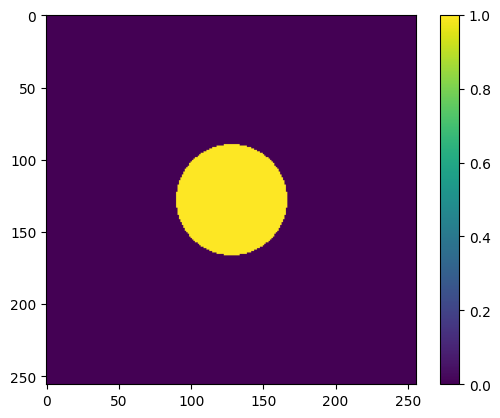

In [33]:
########### define the aperture pupil ap

size = 256
Mm = 2
(w, h) = (size,size)
a, b = (w//2, h//2)
r = diaph *size/(Mm*pupil_rad*2)
#### real coordinate on the pupil
dx = pupil_rad / size
xp = dx * (np.linspace(-size//2,size//2,size))

xxp,yyp     = np.meshgrid(xp,xp)

print (xxp.shape)
##### left to the students: TRY TO PUT IT IN ABSOLUTE TERMS BY DEINIFING THE PIXEL SIZE ETC...
y,x = np.ogrid[-a:w-a, -b:h-b]
x,y = (x/r,y/r)

circle = x*x + y*y <= 1
mask_comp = ~circle

ap = np.zeros((w, h))
ap[circle] = 1
plt.imshow(ap)
plt.colorbar()

Now we can add it as phase to our psf calculations


For instance, let's define defocus

This is our aperture $A$. For the aberration free case, the Airy pattern $p$ is calculated by
$$ p = |\mathcal{F}(A e^{2 \pi i \phi})|^2, $$
where $\mathcal{F}$ is the Fourier transform.

It's very easy to calculate:

1.2913223140495869 (256, 256) (256, 256)
0.0603907905732379


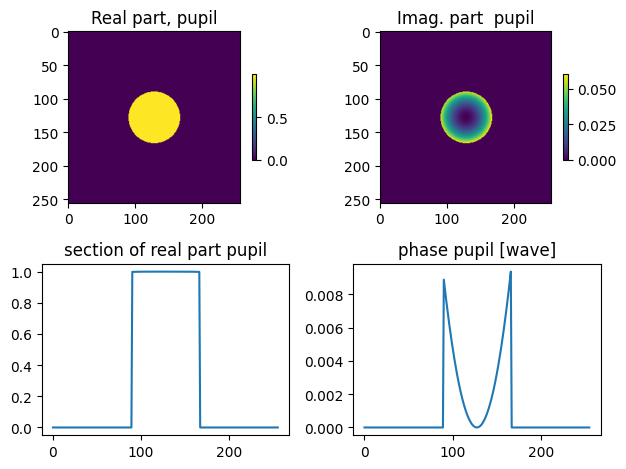

In [34]:
#### defocus component of the wave front

def Defocus(x,y,R,dR):
  Complex_defocus     = np.exp( 1j * dR*(x**2 + y**2) / R**2)
  return Complex_defocus

###Comnplex_defocus is the phase contribution to the pupil
focal   = 22      ### mm

R       = focal ###curvature radius  CHANGE HERE THE PARAMETER TO TRY
dR      = 2  ### defocus parawmeter in mm. TRY TO CHANGE IT HERE

Complex_defocus = Defocus(xxp,yyp,R,dR)
print (np.angle(Complex_defocus).max(),xxp.shape,Complex_defocus.shape)
## compute the cooprdinates in the image plane
wave    = 0.55e-3 ### mm
xprime    = wave * focal * np.fft.fftfreq( x[0].size , x[0,1]-x[0,0])

#apD     = defocus * ap         #### this is the aberrate pupil
Complex_defocus[mask_comp] = 0         #### this is the aberrate pupil
apD = Complex_defocus
print (np.angle(apD).max())

#### now show the pupil
F,A     = plt.subplots(2,2,gridspec_kw={'width_ratios': [1, 1]})
imR      = A[0,0].imshow(apD.real )
A[0,0].set_title('Real part, pupil')
plt.colorbar(imR,ax=A[0,0],shrink=0.5)

imI      = A[0,1].imshow(apD.imag )
A[0,1].set_title('Imag. part  pupil')
plt.colorbar(imI,ax=A[0,1],shrink=0.5)

A[1,0].plot(apD.real[size//2,:])
A[1,0].set_title('section of real part pupil')

A[1,0].set_box_aspect(A[0,0].get_box_aspect())  # Match the aspect ratio to the left plot
angolo = np.angle(apD)/(2*np.pi)
A[1,1].plot(angolo[size//2,:])
A[1,1].set_title('phase pupil [wave]')

A[1,1].set_box_aspect(A[0,0].get_box_aspect())  # Match the aspect ratio to the left plot

plt.tight_layout()  # Optimize layout






In [ ]:
#### now we compute the airy function or the PSF
### use use the defocused pupil that is apD

airy = np.abs(np.fft.fftshift(np.fft.fft2(apD)))**2

# don't forget fftshift and ifftshift!

defPSF  = airy
sizeL   = defPSF.shape[0]

print (sizeL)

xx,yy     = np.meshgrid(x[0,:],y[0,:])
dx        = x[0,1]-x[0,0]
print(xx.shape)
############ show it
F1,A1 = plt.subplots(1,2)
F1.suptitle('defocused PSF',y=0.85)

A1[0].imshow(defPSF)
A1[0].set_title('full size PSF over:'+str(np.round(xx.max(),1))+'[um]')

#zoom in
crop    =   20
A1[1].imshow(defPSF[a-crop:a+crop,b-crop:b+crop],cmap='hot')
A1[1].set_title('PSF over:'+str(np.round(xx[0,b-crop:b+crop].max(),1))+'[um]')

########### comnpute the MTF
MTF   = np.abs(np.fft.fftshift(np.fft.fft2(defPSF)))
frequenze   = np.fft.fftshift(np.fft.fftfreq(sizeL,dx))
plt.figure()
m     =90
i0    = sizeL//2 - m
i1    = sizeL//2 + m
print (sizeL,i0,i1,MTF.shape,MTF[sizeL//2,sizeL//2+m])
plt.plot(frequenze[i0:i1], MTF[sizeL//2 , i0:i1])
plt.xlabel('spatial freq [1/mm]')
plt.ylabel('Modul. Tranf. Funct.')
plt.title('Modulation Transfwer Function')

now load an image froim the library and apply the convolutiuon to it with the PSF

In [ ]:
from skimage import data
from skimage.color import rgb2gray
from scipy.signal import convolve2d

cat = data.chelsea()
print(cat.shape)

gray_cat = rgb2gray(cat)
plt.imshow(gray_cat,cmap='gray')

catDeconv   = convolve2d(gray_cat,defPSF[a-crop:a+crop,b-crop:b+crop],mode='same')
#####   this is the convolution with the default PSF
plt.figure()
plt.imshow(catDeconv,cmap='gray')

This is the modification of the pupil for astigmatism. The pupil phase has the shape:

$$ P(r) = exp^{i\cdot h^2 \cdot r^2 \cdot cos^2(\theta)}$$

The height of the image  is  "h". The radial and polar coordinates on the pupil plane are "r" and $\theta $.

In [ ]:
#### ASTIGMATISM
def Astigma(xx,yy,Hprime,C20):
  angolo = np.arctan2(yy,xx)
  Complex_AS     = np.exp( 1j * C20 * Hprime**2 * (xx**2 + yy**2) * np.cos(angolo)**2)
  return Complex_AS

### now we compute the airy function or the PSF
C20         = 5 ### 1/mm^3
Hprime      = 1 ## mm
AS_phase    = Astigma(xx,yy,Hprime,C20)
apD         = ap * AS_phase

airy = np.abs(np.fft.fftshift(np.fft.fft2(apD)))**2
 # don't forget fftshift and ifftshift!
defPSF = airy

dx = x[0,1]-x[0,0]
Num     = x.shape[1]
####### create the meshgrid for computatiuon in 2D
xv    = np.linspace(x[0,:].min(),x[0,:].max(),Num)
yv    = np.linspace(x[0,:].min(),x[0,:].max(),Num)

xx,yy     = np.meshgrid(xv,yv)
angolo    = np.arctan2(yy,xx)
prova     =  np.cos(angolo)
prova     = prova * (xx**2 + yy**2)
#  Complex_AS     = np.exp( 1j * C20 * Hprime**2 * (xx**2 + yy**2) * np.cos(angolo)**2)
############ show it
F1,A1 = plt.subplots(1,3)
A1[0].imshow(defPSF)

#zoom in
crop    =   10
A1[1].imshow(defPSF[a-crop:a+crop,b-crop:b+crop],cmap='hot')
im = A1[2].imshow(np.angle(AS_phase),cmap='hot')
plt.colorbar(im,ax=A1[2],shrink=0.5)

from skimage import data
from skimage.color import rgb2gray
from scipy.signal import convolve2d

cat = data.chelsea()

gray_cat = rgb2gray(cat)
plt.figure()
plt.imshow(gray_cat,cmap='gray')

catDeconv   = convolve2d(gray_cat,defPSF[a-crop:a+crop,b-crop:b+crop],mode='same')
#####   this is the convolution with the default PSF
plt.figure()
plt.imshow(catDeconv,cmap='gray')
